## PROJECT: The colorful rainbow of noise

In [1]:
# import all necessary modules
import numpy as np
import matplotlib.pyplot as plt
import scipy.fftpack as fftpack

# White and brown noise

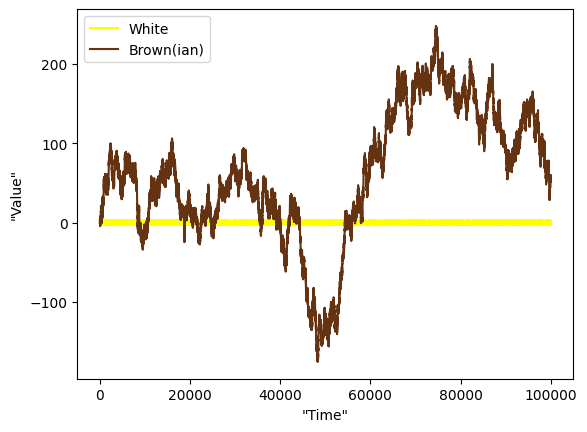

In [2]:
# number of data points
npnts = int( 1e5 )

# create noise signals
whitenoise = np.random.randn(npnts)
brownnoise = np.cumsum(whitenoise)

# plot both on the same graph
plt.plot(whitenoise,color=[1,1,0])
plt.plot(brownnoise,color=[.4,.2,.07])
plt.legend(['White','Brown(ian)'])
plt.xlabel('"Time"')
plt.ylabel('"Value"')
plt.show()



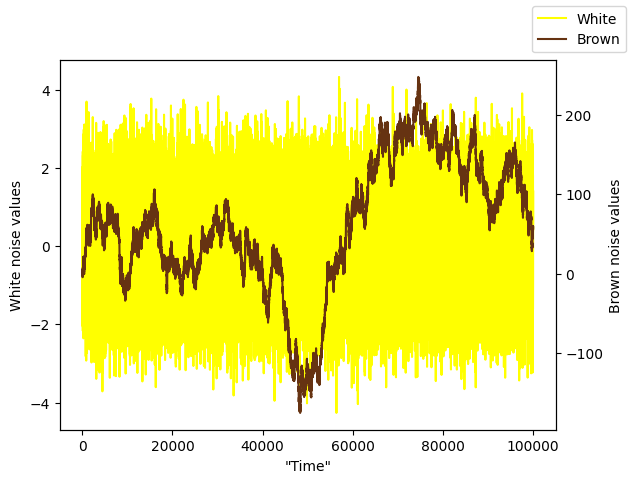

In [3]:
# now plot both on a yy-plot (same axis but different scales for each noise color)
fig,ax = plt.subplots(1)
ax.plot(whitenoise,color=[1,1,0],label='White')
ax.set_ylabel('White noise values')
ax.set_xlabel('"Time"')

ax2 = ax.twinx()
ax2.plot(brownnoise,color=[.4,.2,.07],label='Brown')
ax2.set_ylabel('Brown noise values')
fig.legend()
plt.show()


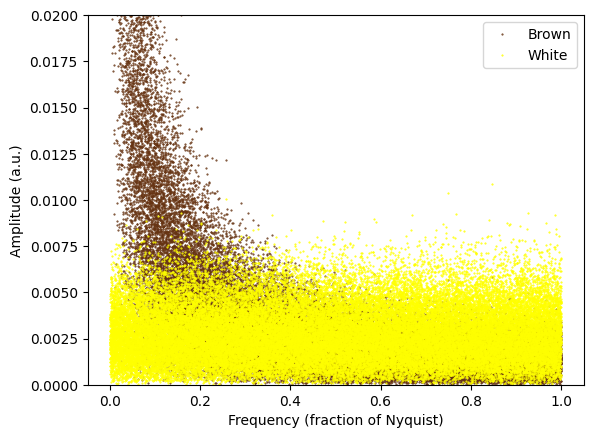

In [4]:
# compute the power spectra
whitenoiseX = np.abs(fftpack.fft(whitenoise)) / npnts
brownnoiseX = np.abs(fftpack.fft(brownnoise)) / npnts

# vector of frequencies (normalized to Nyquist)
frex = np.linspace(0,1,int(npnts/2+1))

# show the power spectra
plt.plot(frex,brownnoiseX[:len(frex)],'.',color=[.4,.2,.07],markersize=1)
plt.plot(frex,whitenoiseX[:len(frex)],'.',color=[1,1,0],markersize=1)

plt.legend(['Brown','White'])
plt.ylim([0,.02])
plt.ylabel('Amplitude (a.u.)')
plt.xlabel('Frequency (fraction of Nyquist)')
plt.show()

# Pink and blue noise

In [6]:
# pink noise

# create a Fourier spectrum
FourierSpect = np.zeros(npnts,dtype=complex)

fc_amp = 1 / (frex+.01) + np.random.randn(int(npnts/2+1))**2*5
fc_phs = 2*np.pi * np.random.rand(int(npnts/2+1))

FourierSpect[:int(npnts/2+1)] = fc_amp * np.exp(1j*fc_phs)
pinknoise = np.real(fftpack.ifft(FourierSpect))

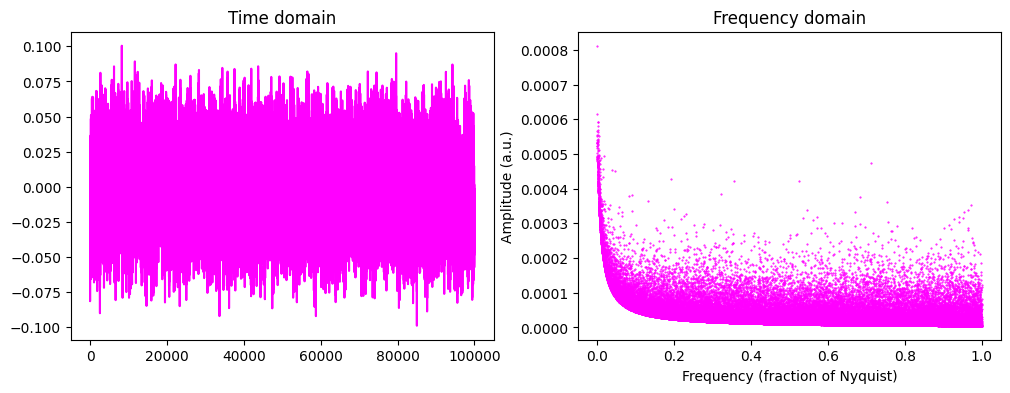

In [7]:

# compute the power spectrum
pinknoiseX = np.abs(fftpack.fft(pinknoise)) / npnts

fig,ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(pinknoise,color=[1,0,1])
ax[0].set_title('Time domain')

ax[1].plot(frex,pinknoiseX[:len(frex)],'.',color=[1,0,1],markersize=1)
ax[1].set_ylabel('Amplitude (a.u.)')
ax[1].set_xlabel('Frequency (fraction of Nyquist)')
ax[1].set_title('Frequency domain')
plt.show()

In [8]:
# blue noise

FourierSpect = np.zeros(npnts,dtype=complex)

fc_amp = np.linspace(1,3,int(npnts/2+1)) + np.random.randn(int(npnts/2+1))/5
fc_phs = 2*np.pi * np.random.rand(int(npnts/2+1))

FourierSpect[:int(npnts/2+1)] = fc_amp * np.exp(1j*fc_phs)
bluenoise = np.real(fftpack.ifft(FourierSpect))


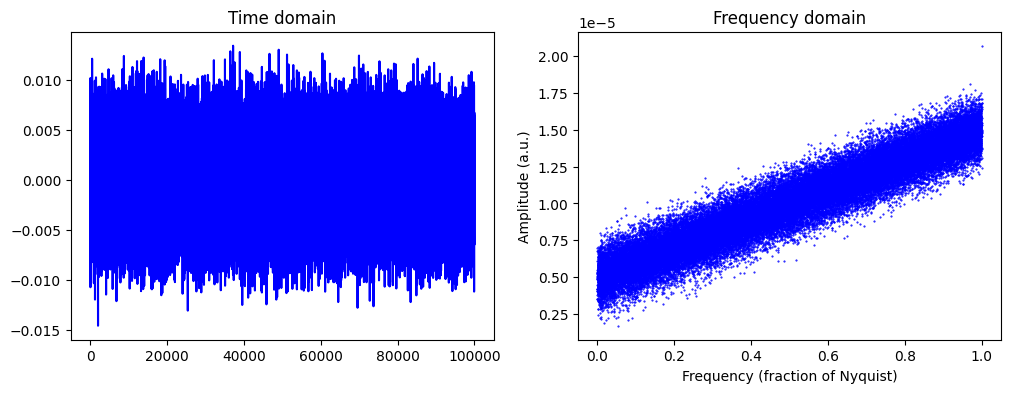

In [9]:

# compute the power spectrum
bluenoiseX = np.abs(fftpack.fft(bluenoise)) / npnts

fig,ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(bluenoise,color=[0,0,1])
ax[0].set_title('Time domain')

ax[1].plot(frex,bluenoiseX[:len(frex)],'.',color=[0,0,1],markersize=1)
ax[1].set_ylabel('Amplitude (a.u.)')
ax[1].set_xlabel('Frequency (fraction of Nyquist)')
ax[1].set_title('Frequency domain')
plt.show()

# The colorful spectrum of the rainbow

In [10]:
# recreate and set amplitude params to match

In [11]:
def whiteNoiseSpect(amp,N):
  noise = amp*np.random.randn(N)
  return abs(fftpack.fft(noise)/N)

def brownNoiseSpect(amp,N):
  noise = np.cumsum( amp*np.random.randn(N) )
  return abs(fftpack.fft(noise)/N)

def pinkNoiseSpect(amp,N):
  FourierSpect = np.zeros(N,dtype=complex)
  fc_amp = 1 / (frex+.01) + np.random.randn(int(N/2+1))**2*5
  fc_phs = 2*np.pi * np.random.rand(int(N/2+1))
  FourierSpect[:int(N/2+1)] = fc_amp * np.exp(1j*fc_phs)
  noise = amp * np.real(fftpack.ifft(FourierSpect))
  return abs(fftpack.fft(noise)/N)

def blueNoiseSpect(amp,N):
  FourierSpect = np.zeros(N,dtype=complex)
  fc_amp = np.linspace(1,3,int(N/2)+1) + np.random.randn(int(N/2+1))/5
  fc_phs = 2*np.pi * np.random.rand(int(N/2+1))
  FourierSpect[:int(N/2+1)] = fc_amp * np.exp(1j*fc_phs)
  noise = amp * np.real(fftpack.ifft(FourierSpect))
  return abs(fftpack.fft(noise)/N)


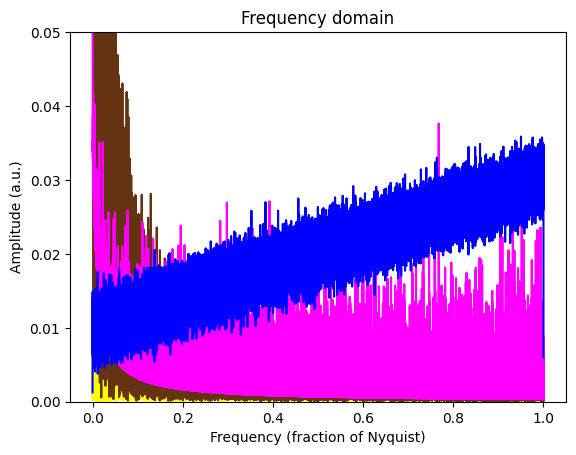

In [12]:
# plot them all in the same graph

plt.plot(frex,whiteNoiseSpect(1,npnts)[:len(frex)],color=[1,1,0])
plt.plot(frex,brownNoiseSpect(1,npnts)[:len(frex)],color=[.4,.2,.07])
plt.plot(frex,pinkNoiseSpect(70,npnts)[:len(frex)],color=[1,0,1])
plt.plot(frex,blueNoiseSpect(2000,npnts)[:len(frex)],color=[0,0,1])

plt.ylim([0,.05])
plt.ylabel('Amplitude (a.u.)')
plt.xlabel('Frequency (fraction of Nyquist)')
plt.title('Frequency domain')
plt.show()

# Bonus: How do they sound?

In [13]:
from IPython.display import Audio

In [14]:
print('White noise')
Audio(whitenoise,rate=44100)

White noise


In [15]:
# To download the file, you can select 'Download' from the 3-dot menu in the audio player, or use the following code:

from scipy.io.wavfile import write
write('whitenoise.wav', 44100, whitenoise)

from google.colab import files
files.download('whitenoise.wav')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
print('Brown noise')
Audio(brownnoise*10,rate=44100)

Brown noise


In [17]:
print('Pink noise')
Audio(pinknoise,rate=44100)

Pink noise


In [18]:
print('Blue noise')
Audio(bluenoise,rate=44100)

Blue noise
